## Pandas Series



### What is Pandas

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

In [1]:
# importing numpy and pandas libraries

import pandas as pd
import numpy as np
import sys

### Series by lists

Series is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index.

https://pandas.pydata.org/docs/reference/api/pandas.Series.html#pandas.Series

In [2]:
# Strings as data
car = ["BMW", "Toyota", "Honda"]

pd.Series(car)

0       BMW
1    Toyota
2     Honda
dtype: object

In [3]:
# Integers as data
price = [45000, 35000, 30000]

pd.Series(price)

0    45000
1    35000
2    30000
dtype: int64

In [4]:
# custom indices
subjects = ["Maths", "Physics", "Chemistry"]
marks = [95, 90, 85]

pd.Series(marks,index=subjects)

Maths        95
Physics      90
Chemistry    85
dtype: int64

In [5]:
# setting name for series and index
marks_series = pd.Series(marks, index=subjects,name="Marks Obtained", dtype=np.int32)
marks_series.index.name = "Subjects"
marks_series    

Subjects
Maths        95
Physics      90
Chemistry    85
Name: Marks Obtained, dtype: int32

### Series by dictonaries

In [6]:
marks = {
    "Maths": 95,
    "Physics": 90,
    "Chemistry": 85
}
marks_series = pd.Series(marks, name="Marks Obtained", dtype=np.int32)
marks_series

Maths        95
Physics      90
Chemistry    85
Name: Marks Obtained, dtype: int32

### Series Attributes

In [7]:
# size
marks_series.size

3

In [8]:
# dtype
marks_series.dtype

dtype('int32')

In [9]:
# name
marks_series.name

'Marks Obtained'

In [10]:
# is_unique
marks_series.is_unique

True

In [11]:
num_ser = pd.Series([1,1,2,3,4])
num_ser.is_unique

False

In [12]:
# index
marks_series.index

Index(['Maths', 'Physics', 'Chemistry'], dtype='object')

In [13]:
num_ser.index

RangeIndex(start=0, stop=5, step=1)

In [14]:
# values
marks_series.values

array([95, 90, 85], dtype=int32)

### Series using read_csv

- CSV -> Common separated values
- pd.read_csv is used to import and read the csv files 
- squeeze is used to convert a dataframe into a Series

In [15]:
# with one column
sub_ser = pd.read_csv("./subs.csv").squeeze()
sub_ser

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [16]:
type(sub_ser)

pandas.core.series.Series

In [17]:
# with 2 cols
# importing kholi data
kholi_series = pd.read_csv("./kohli_ipl.csv",index_col="match_no").squeeze()
kholi_series

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

### Head and Tail

- Head provides the top 5 data by default
- Tail provides the bottom 5 data by default

In [18]:
# importing movie data
movie_series = pd.read_csv("./bollywood.csv",index_col="movie").squeeze()
movie_series

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

In [19]:
# head
movie_series.head(6)

movie
Uri: The Surgical Strike                       Vicky Kaushal
Battalion 609                                    Vicky Ahuja
The Accidental Prime Minister (film)             Anupam Kher
Why Cheat India                                Emraan Hashmi
Evening Shadows                             Mona Ambegaonkar
Soni (film)                             Geetika Vidya Ohlyan
Name: lead, dtype: object

In [20]:
# tail
movie_series.tail(4)

movie
Aankhen (2002 film)     Amitabh Bachchan
Saathiya (film)             Vivek Oberoi
Company (film)                Ajay Devgn
Awara Paagal Deewana        Akshay Kumar
Name: lead, dtype: object

### Sample 

- It is used to provide a sample of random data from the given dataset
  

In [21]:
# sample
movie_series.sample(3)

movie
Dunno Y... Na Jaane Kyon      Zeenat Aman
Firaaq                         Inaamulhaq
Shaadi Ke Side Effects      Farhan Akhtar
Name: lead, dtype: object

### Value Counts

- The value_counts() method in pandas is used to count the occurrences of unique values in a Series (a single column of a DataFrame) or the rows in a DataFrame

In [22]:
movie_series.value_counts()

lead
Akshay Kumar         48
Amitabh Bachchan     45
Ajay Devgn           38
Salman Khan          31
Sanjay Dutt          26
                     ..
Seema Azmi            1
Akanksha Puri         1
Charanpreet Insan     1
Jaideep Ahlawat       1
Monali Thakur         1
Name: count, Length: 566, dtype: int64

### Sorting

In [23]:
# sort_values -> in place

# method chaining

highest_score = kholi_series.sort_values(ascending=False).head(1).values[0]
print(highest_score)

113


In [24]:
# for permanent sorting in place
# kholi_series.sort_values(ascending=False, inplace=True)


In [25]:
# sort_index -> sorts by index labels
movie_series.sort_index()

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object

### Series Math Methods

In [26]:
# count

kholi_series.count()

np.int64(215)

In [27]:
# sum
sub_ser.sum()

np.int64(49510)

In [28]:
# mean
sub_ser.mean()

np.float64(135.64383561643837)

In [29]:
# median

kholi_series.median()

np.float64(24.0)

In [30]:
# mode

movie_series.mode()

0    Akshay Kumar
Name: lead, dtype: object

In [31]:
# standard deviation and variance
print("Standard Deviation:",sub_ser.std())
print("Variance:",sub_ser.var())

Standard Deviation: 62.6750230372527
Variance: 3928.1585127201565


In [32]:
# min and max
print("Minimum:",kholi_series.min())
print("Maximum:",kholi_series.max())

Minimum: 0
Maximum: 113


### Describe

- Gives a summary in one go

In [33]:
kholi_series.describe()

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64

### Series Indexing

In [34]:
x = pd.Series([1,3,4,7,8,9,0,1])
x

0    1
1    3
2    4
3    7
4    8
5    9
6    0
7    1
dtype: int64

In [35]:
# indexing
# negative indexing won't work for non-string index
try:
    print(x[1])
    print(x[-1])
except Exception as err:
    print("Negative indexing won't work, error occured",err)

3
Negative indexing won't work, error occured -1


### iloc and .loc
- .iloc[] is primarily integer position based (from 0 to length-1 of the axis), but may also be used with a boolean array.
- .loc[] is primarily used for label-based access (index names, column names)

In [36]:
# normal indexing
print(movie_series.iloc[0],"\n")

# fancy indexing
print(movie_series.iloc[[1,4]],"\n")

# negative indexing without .iloc
print(movie_series.iloc[-1],"\n")

# label based indexing
print(movie_series.loc["1920 (film)"])

Vicky Kaushal 

movie
Battalion 609           Vicky Ahuja
Evening Shadows    Mona Ambegaonkar
Name: lead, dtype: object 

Akshay Kumar 

Rajniesh Duggall


### Slicing

In [37]:
# slicing
movie_series.iloc[1:4]

movie
Battalion 609                             Vicky Ahuja
The Accidental Prime Minister (film)      Anupam Kher
Why Cheat India                         Emraan Hashmi
Name: lead, dtype: object

In [38]:
# negative slicing
movie_series.iloc[-5:]

movie
Hum Tumhare Hain Sanam      Shah Rukh Khan
Aankhen (2002 film)       Amitabh Bachchan
Saathiya (film)               Vivek Oberoi
Company (film)                  Ajay Devgn
Awara Paagal Deewana          Akshay Kumar
Name: lead, dtype: object

In [39]:
movie_series.iloc[::2]

movie
Uri: The Surgical Strike                   Vicky Kaushal
The Accidental Prime Minister (film)         Anupam Kher
Evening Shadows                         Mona Ambegaonkar
Fraud Saiyaan                               Arshad Warsi
Manikarnika: The Queen of Jhansi          Kangana Ranaut
                                              ...       
Raaz (2002 film)                              Dino Morea
Waisa Bhi Hota Hai Part II                  Arshad Warsi
Kaante                                  Amitabh Bachchan
Aankhen (2002 film)                     Amitabh Bachchan
Company (film)                                Ajay Devgn
Name: lead, Length: 750, dtype: object

In [40]:
movie_series.iloc[[1,7,9]]

movie
Battalion 609               Vicky Ahuja
Bombairiya                 Radhika Apte
Thackeray (film)    Nawazuddin Siddiqui
Name: lead, dtype: object

### Editing

In [41]:
marks_series

Maths        95
Physics      90
Chemistry    85
Name: Marks Obtained, dtype: int32

In [42]:
# indexing
marks_series.iloc[0] = 100
marks_series

Maths        100
Physics       90
Chemistry     85
Name: Marks Obtained, dtype: int32

In [43]:
# if value is ot existed, new will create a new value in series
marks_series.loc["Social studies"] = 89
marks_series

Maths             100
Physics            90
Chemistry          85
Social studies     89
Name: Marks Obtained, dtype: int32

In [44]:
# slicing
marks_series.iloc[2:4] = [99,99]
marks_series

/tmp/ipykernel_1739/1151582432.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[99, 99]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  marks_series.iloc[2:4] = [99,99]


Maths             100
Physics            90
Chemistry          99
Social studies     99
Name: Marks Obtained, dtype: int64

In [45]:
# fancy indexing
marks_series.iloc[[1,3]] = [92,100]
marks_series 

Maths             100
Physics            92
Chemistry          99
Social studies    100
Name: Marks Obtained, dtype: int64

In [46]:
# using index label
movie_series.loc["1920 (film)"] = "Adah Sharma"
movie_series.loc["1920 (film)"]

'Adah Sharma'

### Copy and Views

### Series with Python Functionalities

In [47]:
# len/type/sorted/min/max/dir
print(len(sub_ser))
print(type(sub_ser))
print(dir(sub_ser))
print(min(sub_ser))
print(max(sub_ser))
print(sorted(sub_ser))

365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__firstlineno__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rd

In [48]:
# type conversion
# series -> list
list(marks_series)

[100, 92, 99, 100]

In [49]:
# series -> dict
dict(marks_series)

{'Maths': np.int64(100),
 'Physics': np.int64(92),
 'Chemistry': np.int64(99),
 'Social studies': np.int64(100)}

In [50]:
# membership operator
# by default in operator works based on index values
"1920 (film)" in movie_series

True

In [51]:
# memebership operator value wise
"Adah Sharma" in movie_series

False

In [52]:
"Adah Sharma" in movie_series.values

True

In [53]:
# looping
# looping works based on values
for i in movie_series:
    print(i)

Vicky Kaushal
Vicky Ahuja
Anupam Kher
Emraan Hashmi
Mona Ambegaonkar
Geetika Vidya Ohlyan
Arshad Warsi
Radhika Apte
Kangana Ranaut
Nawazuddin Siddiqui
Ali Asgar
Ranveer Singh
Prit Kamani
Ajay Devgn
Sushant Singh Rajput
Amitabh Bachchan
Abhimanyu Dasani
Talha Arshad Reshi
Nawazuddin Siddiqui
Garima Agarwal
Rasika Agashe
Barun Sobti
Akshay Kumar
Zaheer Iqbal
Vidyut Jammwal
Deepika Amin
Manav Kaul
Naseeruddin Shah
Varun Dhawan
Shreyas Talpade
Tiger Shroff
Boman Irani
Ajay Devgn
Arjun Kapoor
Gavie Chahal
Prabhu Deva
Shahid Kapoor
Ayushmann Khurrana
Anupam Kher
Karanvir Bohra
Hrithik Roshan
Jimmy Sheirgill
John Abraham
Rishi Kapoor
Kangana Ranaut
Natalia Janoszek
Diljit Dosanjh
Sidharth Malhotra
Rajeev Khandelwal
Zaira Wasim
Akshay Kumar
Jacqueline Fernandez
Ayushmann Khurrana
Akshaye Khanna
Sonam Kapoor
Karan Deol
Sanjay Dutt
Bhavesh Kumar
Sanaya Irani
Ayushmann Khurrana
Siddhanth Kapoor
Akshay Kumar
Taapsee Pannu
Rajkummar Rao
Sunny Singh Nijjar
Neil Nitin Mukesh
Suraj Pancholi
Boman Iran

In [54]:
# to print movies
for i in movie_series.index:
    print(i)

Uri: The Surgical Strike
Battalion 609
The Accidental Prime Minister (film)
Why Cheat India
Evening Shadows
Soni (film)
Fraud Saiyaan
Bombairiya
Manikarnika: The Queen of Jhansi
Thackeray (film)
Amavas
Gully Boy
Hum Chaar
Total Dhamaal
Sonchiriya
Badla (2019 film)
Mard Ko Dard Nahi Hota
Hamid (film)
Photograph (film)
Risknamaa
Mere Pyare Prime Minister
22 Yards
Kesari (film)
Notebook (2019 film)
Junglee (2019 film)
Gone Kesh
Albert Pinto Ko Gussa Kyun Aata Hai?
The Tashkent Files
Kalank
Setters (film)
Student of the Year 2
PM Narendra Modi
De De Pyaar De
India's Most Wanted (film)
Yeh Hai India
Khamoshi (2019 film)
Kabir Singh
Article 15 (film)
One Day: Justice Delivered
Hume Tumse Pyaar Kitna
Super 30 (film)
Family of Thakurganj
Batla House
Jhootha Kahin Ka
Judgementall Hai Kya
Chicken Curry Law
Arjun Patiala
Jabariya Jodi
Pranaam
The Sky Is Pink
Mission Mangal
Saaho
Dream Girl (2019 film)
Section 375
The Zoya Factor (film)
Pal Pal Dil Ke Paas
Prassthanam
P Se Pyaar F Se Faraar
Ghost 

In [55]:
# Arithmetic Operators(Broadcasting)

100 - marks_series

Maths             0
Physics           8
Chemistry         1
Social studies    0
Name: Marks Obtained, dtype: int64

In [56]:
# relational operators

kholi_series >= 50

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

### Boolean Indexing

In [57]:
# find the number of 50's and 100's scored by kholi
kholi_series[kholi_series >= 50].size

50

In [58]:
# find the number of ducks scored by kholi
kholi_series[kholi_series == 0].size

9

In [59]:
# count the number of days when i had  more than 200 subs a day
sub_ser[sub_ser >= 200].size

59

In [60]:
# find the ators who have done more than 20 films 
num_movies = movie_series.value_counts()
num_movies[num_movies >= 20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64

### Plotting

<Axes: >

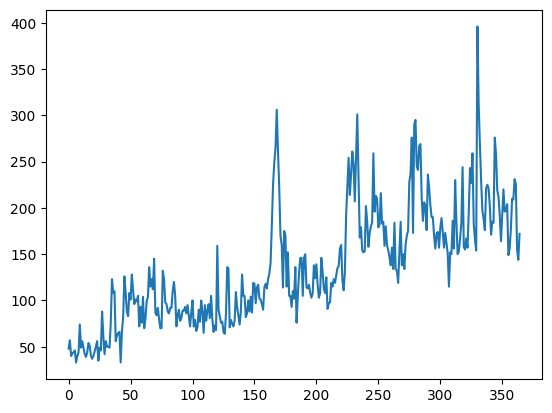

In [61]:
sub_ser.plot()

<Axes: xlabel='lead'>

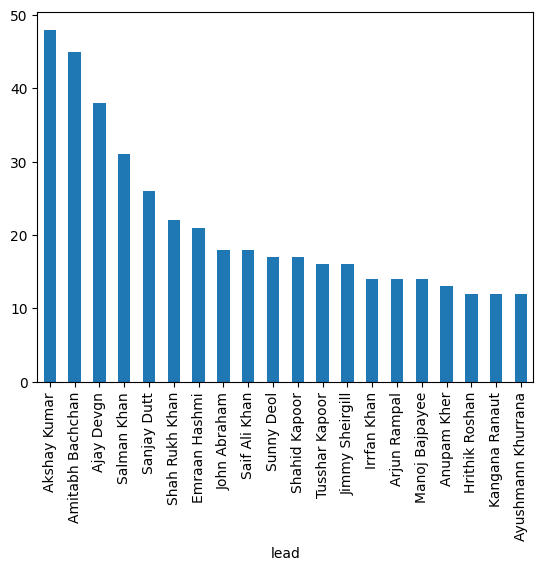

In [62]:
# top 20 actors bar chart
movie_series.value_counts().head(20).plot(kind='bar')

### Some important Series Methods

In [63]:
# astype -> used to change the data type of Series
sys.getsizeof(kholi_series)

3472

In [64]:
sys.getsizeof(kholi_series.astype("int16"))

2182

In [67]:
# between
kholi_series[kholi_series.between(40,55)].size

25

In [69]:
# clip
"""
The pandas.Series.clip() method is used to trim values at specific input thresholds. It replaces values outside the defined boundaries with the boundary values themselves. 
"""

sub_ser.clip(100,200)

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [70]:
# drop duplicates
temp = pd.Series([1,1,2,2,2,3,3,3,4,5,6])
temp

0     1
1     1
2     2
3     2
4     2
5     3
6     3
7     3
8     4
9     5
10    6
dtype: int64

In [71]:
temp.drop_duplicates()

0     1
2     2
5     3
8     4
9     5
10    6
dtype: int64

In [73]:
# how to find wether a data set has duplicates
temp.duplicated().sum()

np.int64(5)

In [77]:
# isnull
miss_arr = pd.Series([1,np.nan,2,4,6,7,np.nan])
miss_arr.isnull().sum()

np.int64(2)

In [81]:
# dropna -> provides a new series without any missing values
miss_arr.dropna()

0    1.0
2    2.0
3    4.0
4    6.0
5    7.0
dtype: float64

In [82]:
# fillna ->  replcaes the missing values
miss_arr.fillna(0)

0    1.0
1    0.0
2    2.0
3    4.0
4    6.0
5    7.0
6    0.0
dtype: float64

In [85]:
# isin
kholi_series[kholi_series.isin([70,100])]

match_no
52      70
120    100
152     70
164    100
Name: runs, dtype: int64

In [91]:
# apply -> used to apply custom logic to all instances of the data set
movie_series.apply(lambda x:x.split()[0].upper())

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: object

In [97]:
sub_ser.apply(lambda x:"good day" if x > sub_ser.mean() else "bad day")

0       bad day
1       bad day
2       bad day
3       bad day
4       bad day
         ...   
360    good day
361    good day
362    good day
363    good day
364    good day
Name: Subscribers gained, Length: 365, dtype: object

In [ ]:
# copy -> makes a copy 
new_copy = kholi_series.head().copy()
new_copy

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [101]:
new_copy[1] = 100
new_copy

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64

In [102]:
kholi_series

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64